<a href="https://colab.research.google.com/github/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/blob/main/ERC_bg_token.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

import re, json, requests
from pathlib import Path

def blob_to_raw(url: str) -> str:
    # Converts:
    # https://github.com/<user>/<repo>/blob/<branch>/<path>
    # -> https://raw.githubusercontent.com/<user>/<repo>/<branch>/<path>
    m = re.match(r"https?://github\.com/([^/]+)/([^/]+)/blob/([^/]+)/(.*)", url)
    if not m:
        return url
    user, repo, branch, path = m.group(1), m.group(2), m.group(3), m.group(4)
    return f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{path}"

def download(url: str, out_path: str, timeout=30):
    raw = blob_to_raw(url)
    r = requests.get(raw, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"Download failed ({r.status_code}) for: {raw}")
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "wb") as f:
        f.write(r.content)
    return out_path, raw, len(r.content)

def list_repo_root(user: str, repo: str, branch: str="main"):
    api = f"https://api.github.com/repos/{user}/{repo}/contents?ref={branch}"
    r = requests.get(api, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"GitHub API failed ({r.status_code}): {api}")
    data = r.json()
    return [x["name"] for x in data if x.get("type") == "file"]

def guess_and_download(user, repo, branch="main"):
    files = list_repo_root(user, repo, branch)
    print("Repo root files:", files)

    # Heuristics: look for sample_image and sample_image_mask (any extension)
    img_candidates  = [f for f in files if re.match(r"MAX_0185_enhanced_final.jpg\.(jpg|jpeg)$", f, re.I)]
    msk_candidates  = [f for f in files if re.match(r"MAX_0185_enhanced_final.png\.(png|jpg|jpeg)$", f, re.I)]

    # If not found in root, user likely put them elsewhere. We'll still keep it simple here.
    if not img_candidates:
        # fallback: any file containing 'sample_image' and image extension
        img_candidates = [f for f in files if ("sample_image" in f.lower()) and re.search(r"\.(jpg|jpeg|png|webp)$", f.lower())]
    if not msk_candidates:
        msk_candidates = [f for f in files if ("mask" in f.lower()) and re.search(r"\.(mask|png|jpg|jpeg)$", f.lower())]

    if not img_candidates:
        raise RuntimeError("Could not find sample_image.* in repo root. Check path or filename.")
    if not msk_candidates:
        raise RuntimeError("Could not find sample_image_mask.* (or mask-like file) in repo root. Check path or filename.")

    img_name = img_candidates[0]
    msk_name = msk_candidates[0]

    img_raw = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{img_name}"
    msk_raw = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{msk_name}"

    img_path, _, _ = download(img_raw, "/content/sample_image_auto")
    msk_path, _, _ = download(msk_raw, "/content/sample_mask_auto")

    return img_raw, msk_raw, img_path, msk_path

In [4]:

IMG_URL = "https://github.com/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/blob/main/MAX_0185_enhanced_final.jpg"
MSK_URL = "https://github.com/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/blob/main/MAX_0185_enhanced_final.png"

try:
    img_path, img_raw, img_bytes = download(IMG_URL, "/content/sample_image")
    msk_path, msk_raw, msk_bytes = download(MSK_URL, "/content/sample_mask")
    print("Downloaded OK:")
    print(" IMG:", img_raw, img_bytes, "bytes")
    print(" MSK:", msk_raw, msk_bytes, "bytes")
except Exception as e:
    print("Direct download failed:", e)
    print("Falling back to repo auto-guess...")
    img_raw, msk_raw, img_path, msk_path = guess_and_download(
        user="minjilee-purdue",
        repo="erc_tree_semantic_segmentation_in_mlops",
        branch="main"
    )
    print("Auto-selected:")
    print(" IMG:", img_raw)
    print(" MSK:", msk_raw)
    print(" Local paths:", img_path, msk_path)

Downloaded OK:
 IMG: https://raw.githubusercontent.com/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/main/MAX_0185_enhanced_final.jpg 4639780 bytes
 MSK: https://raw.githubusercontent.com/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/main/MAX_0185_enhanced_final.png 210208 bytes


Image shape: (3648, 5472, 3)
Mask loaded using: PIL


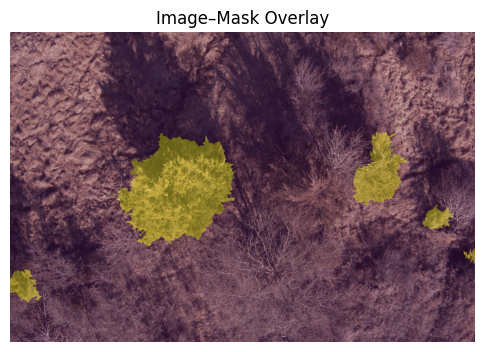

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_PATH = "/content/sample_image"
MSK_PATH = "/content/sample_mask"

# 1) Load RGB image
img = Image.open(IMG_PATH).convert("RGB")
img_np = np.array(img)
H, W = img_np.shape[:2]
print("Image shape:", img_np.shape)

# 2) Load mask with multiple format fallbacks
def load_mask_any(path, target_hw):
    """
    Attempts to load a mask file that may be stored in different formats:
    - PNG/JPG (even if extension is .mask)
    - NumPy array
    - Raw binary (uint8 / uint16 / uint32)
    Returns a binary mask resized to target_hw.
    """
    H, W = target_hw

    # (A) Try loading via PIL
    try:
        m = Image.open(path)
        m_np = np.array(m)
        if m_np.ndim == 3:
            m_np = m_np[..., 0]
        if m_np.shape[:2] != (H, W):
            m_np = np.array(
                Image.fromarray(m_np).resize((W, H), resample=Image.NEAREST)
            )
        return (m_np > 0).astype(np.uint8), "PIL"
    except:
        pass

    # (B) Check if NumPy format
    with open(path, "rb") as f:
        if f.read(6).startswith(b"\x93NUMPY"):
            arr = np.load(path)
            if arr.shape != (H, W):
                arr = np.array(
                    Image.fromarray(arr.astype(np.uint8)).resize((W, H), Image.NEAREST)
                )
            return (arr > 0).astype(np.uint8), "NPY"

    # (C) Raw binary fallback
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == H * W:
        return data.reshape(H, W), "RAW_uint8"

    raise RuntimeError("Unknown mask format")

mask_np, mask_mode = load_mask_any(MSK_PATH, (H, W))
print("Mask loaded using:", mask_mode)

# 3) Visualize image + mask overlay
plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.imshow(mask_np, alpha=0.35)
plt.title("Image–Mask Overlay")
plt.axis("off")
plt.show()